In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
data=pd.read_csv("car_fuel_efficiency_2026.csv")

In [3]:
data.columns.str.lower().str.replace(" ","_")

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'fuel_efficiency_mpg'],
      dtype='str')

In [4]:
cols=['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']
df=data[cols]

In [5]:
df.describe()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
count,10000.000000,9123.000000,10000.000000,10000.000000,10000.000000
mean,2268.807000,254.446016,4286.754000,1999.549500,29.997700
std,183.447355,22.844613,266.212491,14.207925,2.930245
min,1590.000000,171.000000,3320.000000,1975.000000,19.800000
25%,2150.000000,239.000000,4110.000000,1987.000000,28.000000
50%,2270.000000,254.000000,4280.000000,2000.000000,30.000000
75%,2390.000000,270.000000,4470.000000,2012.000000,31.900000
max,3110.000000,334.000000,5460.000000,2024.000000,41.200000


In [6]:
#Q1
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  10000 non-null  int64  
 1   horsepower           9123 non-null   float64
 2   vehicle_weight       10000 non-null  int64  
 3   model_year           10000 non-null  int64  
 4   fuel_efficiency_mpg  10000 non-null  float64
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [7]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [8]:
len(df)

10000

In [9]:
df.head(5)

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


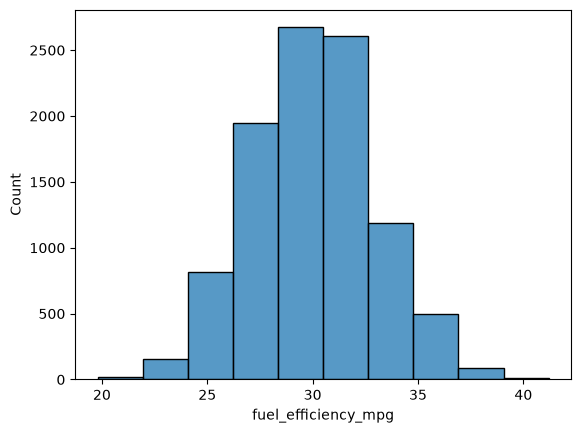

In [10]:
sns.histplot(df['fuel_efficiency_mpg'],bins=10)
plt.show()

In [11]:
#Q2
df['horsepower'].median()

np.float64(254.0)

In [12]:
#Q3
#1) Filling null values with zeroes
df0=df.copy()
df0['horsepower']=df0['horsepower'].fillna(0)

In [13]:
df0.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [14]:
n = len(df0)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df0.iloc[idx[:n_train]]
df_val = df0.iloc[idx[n_train:n_train + n_val]]
df_test = df0.iloc[idx[n_train + n_val:]]

In [15]:
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [16]:
def dot(xi, w):
    n = len(xi)
    
    res = 0.0
    
    for j in range(n):
        res = res + xi[j] * w[j]
    
    return res

In [17]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [18]:
X_train=df_train.copy()
Y_train=np.log1p(df_train['fuel_efficiency_mpg'])
del X_train['fuel_efficiency_mpg']

In [19]:
w0, w = train_linear_regression(X_train, Y_train)
y_pred = w0 + X_train.dot(w)

In [20]:
w0

np.float64(-2.548879880787878)

In [21]:
w

array([-4.93996322e-05,  3.99285304e-06, -1.29300047e-04,  3.32220821e-03])

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

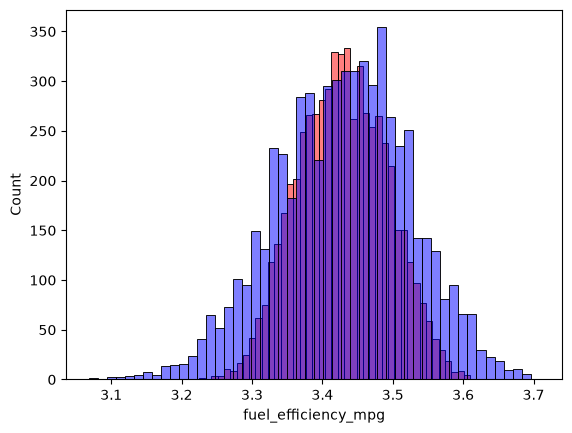

In [22]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(Y_train, color='blue', alpha=0.5, bins=50)

In [23]:
#rmse
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [24]:
rmse_0=round(rmse(Y_train, y_pred),3)
rmse_0

np.float64(0.071)

In [25]:
#2) Filling the missing values with mean
df_mean=df.copy()
df_mean['horsepower']=df_mean['horsepower'].fillna(df['horsepower'].mean())

In [26]:
df_mean.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
fuel_efficiency_mpg    0
dtype: int64

In [27]:
n = len(df_mean)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df_mean.iloc[idx[:n_train]]
df_val = df_mean.iloc[idx[n_train:n_train + n_val]]
df_test = df_mean.iloc[idx[n_train + n_val:]]

In [28]:
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [29]:
X_train=df_train.copy()
Y_train=np.log1p(df_train['fuel_efficiency_mpg'].values)
del X_train['fuel_efficiency_mpg']

In [30]:
w0, w = train_linear_regression(X_train, Y_train)
y_pred = w0 + X_train.dot(w)

In [31]:
w0

np.float64(-2.5458454588229125)

In [32]:
w

array([-3.44295192e-05, -1.93776986e-04, -1.27256856e-04,  3.32445490e-03])

<Axes: ylabel='Count'>

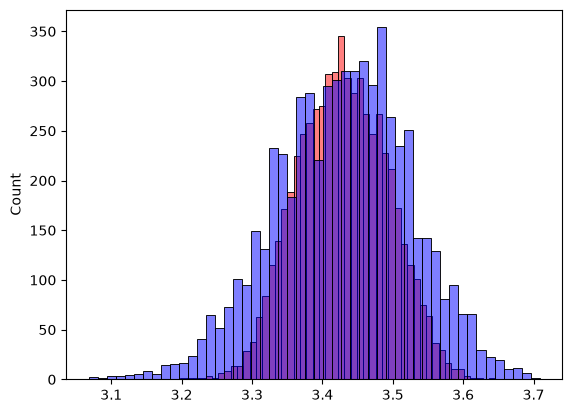

In [33]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(Y_train, color='blue', alpha=0.5, bins=50)

In [34]:
rmse_mean=round(rmse(Y_train, y_pred),3)
rmse_mean

np.float64(0.071)

In [35]:
rmse_0>rmse_mean

np.False_

**RMSE of model where data has values imputated with 0 is slightly higher compared to the model trained on data with mean values imputated in it. So the latter case has better RMSE**

In [36]:
#Q4
df_train = df0.iloc[idx[:n_train]]
df_val = df0.iloc[idx[n_train:n_train + n_val]]
df_test = df0.iloc[idx[n_train + n_val:]]

In [37]:
X_train=df_train.copy()
Y_train=np.log1p(df_train['fuel_efficiency_mpg'].values)
del X_train['fuel_efficiency_mpg']
X_val=df_val.copy()
del X_val['fuel_efficiency_mpg']

In [38]:
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

In [39]:
X_val

,engine_displacement,horsepower,vehicle_weight,model_year
2480,2240,265.0,3990,2004
289,2390,259.0,4770,2019
6086,2360,265.0,4320,2018
3075,2430,279.0,4430,2008
8123,2220,249.0,4030,1999
...,...,...,...,...
1638,1980,229.0,4140,2020
5891,2590,263.0,4630,1989
7427,2390,264.0,4550,2017
608,2330,244.0,4440,2014


In [40]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [41]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train.values, Y_train, r=r)
    y_pred = w0 + X_val.values.dot(w)
    score = round(rmse(y_val, y_pred),4)
    
    print(r, w0, score)

0 -2.548879880787878 0.0715
0.01 -2.456525696928604 0.0715
0.1 -1.8524448492907521 0.0717
1 -0.535529553803343 0.0727
5 -0.1287451934306354 0.0733
10 -0.06603998348984993 0.0734
100 -0.006760761337059787 0.0735


In [42]:
#Q5
score_list=[]
n = len(df0)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test
for i in range(10):

    np.random.seed(i)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df0.iloc[idx[:n_train]]
    df_val = df0.iloc[idx[n_train:n_train + n_val]]
    df_test = df0.iloc[idx[n_train + n_val:]]

    X_train=df_train.copy()
    Y_train=np.log1p(df_train['fuel_efficiency_mpg'].values)
    del X_train['fuel_efficiency_mpg']
    X_val=df_val.copy()
    del X_val['fuel_efficiency_mpg']

    y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
    y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

    w0, w = train_linear_regression(X_train.values, Y_train)
    y_pred = w0 + X_val.values.dot(w)
    score = rmse(y_val, y_pred)
    score_list.append(score)
    

In [43]:
score_list

[np.float64(0.07222016116435427),
 np.float64(0.07085480962390553),
 np.float64(0.07001674410142289),
 np.float64(0.07160947080490032),
 np.float64(0.07121934602793346),
 np.float64(0.07272074319560708),
 np.float64(0.07363981939829586),
 np.float64(0.07093670406151323),
 np.float64(0.07159357901409524),
 np.float64(0.07162894692635216)]

In [44]:
round(np.std(score_list),3)

np.float64(0.001)

In [45]:
#Q6
np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df0.iloc[idx[:n_train]]
df_val = df0.iloc[idx[n_train:n_train + n_val]]
df_test = df0.iloc[idx[n_train + n_val:]]

df_train=pd.concat([df_train,df_val])

X_train=df_train.copy()
X_test=df_test.copy()
Y_train=np.log1p(df_train['fuel_efficiency_mpg'].values)
del X_train['fuel_efficiency_mpg']
del X_test['fuel_efficiency_mpg']
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

w0, w = train_linear_regression_reg(X_train, Y_train,r=0.001)
y_pred = w0 + X_test.values.dot(w)
score = rmse(y_test, y_pred)

In [46]:
score

np.float64(0.07213088684591222)